# Entender `Potential`

Este notebook explica, con ejemplos pequenos, como se construye y como se usa `classes.potential.Potential`.

La idea central del codigo es representar un potencial electrostatico 2D como:

- una parte media independiente del tiempo: `fields[0]`;
- una lista de fluctuaciones complejas: `fields[1]`;
- una frecuencia por fluctuacion: `freqs`.

`Potential` no integra trayectorias por si solo. Guarda la malla, valida los campos, reinterpola si hace falta, y prepara operaciones como interpolacion espacial y gyroaverage. `PotentialSystem` usa despues ese objeto para calcular la dinamica.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

PROJECT_ROOT

PosixPath('/home/juan/Proyectos/GC2D_intranet')

In [2]:
%matplotlib inline

import tempfile

import h5py
import matplotlib.pyplot as plt
import numpy as np

from classes import Potential, PotentialSystem
from workflows.potentials import extract_potential, mock_potential
from workflows.plotting import plot_potential

## 1. Construir un potencial mock

`mock_potential(A, M, nx, ny, seed)` genera un campo periodico en una malla regular. Internamente crea modos de Fourier con amplitud decreciente y fases aleatorias.

En el objeto resultante:

- `x`, `y`: mallas 1D;
- `fields[0]`: valor medio, aqui `None`;
- `fields[1]`: lista de fluctuaciones complejas;
- `freqs`: frecuencia asociada a cada fluctuacion;
- `xy_period`: periodo espacial usado para envolver coordenadas fuera del dominio.

In [3]:
pot = mock_potential(A=0.5, M=8, nx=64, ny=64, seed=27)

print(type(pot).__name__)
print('nx, ny:', pot.nx, pot.ny)
print('dx, dy:', pot.dx, pot.dy)
print('x range:', pot.xmin, pot.xmax)
print('y range:', pot.ymin, pot.ymax)
print('freqs:', pot.freqs)
print('mean field:', pot.fields[0])
print('number of fluctuations:', len(pot.fields[1]))
print('fluctuation shape:', pot.fields[1][0].shape)
print('fluctuation dtype:', pot.fields[1][0].dtype)

Potential
nx, ny: 64 64
dx, dy: 0.09817477042468103 0.09817477042468103
x range: 0.0 6.1850105367549055
y range: 0.0 6.1850105367549055
freqs: [-1]
mean field: None
number of fluctuations: 1
fluctuation shape: (64, 64)
fluctuation dtype: complex128


## 2. Ver el campo complejo

Cada fluctuacion es compleja. La parte real e imaginaria se guardan porque despues `PotentialSystem` reconstruye la dependencia temporal con fases complejas.

Para una fluctuacion `phi_c(x, y)` y frecuencia `freq`, la contribucion temporal usada por `PotentialSystem` es, de forma esquematica:

`2 * real(phi_c(x, y) * exp(1j * freq * t))`

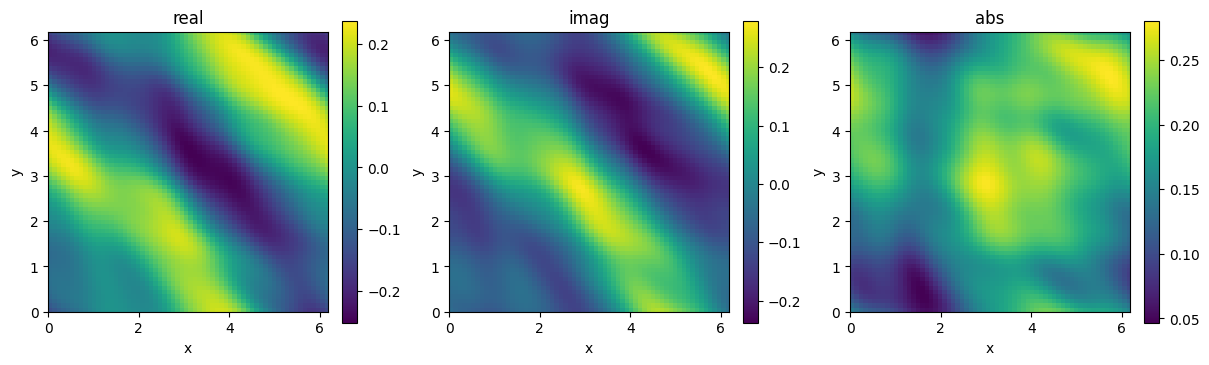

In [4]:
fluct = pot.fields[1][0]

fig, axs = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
for ax, data, title in [
    (axs[0], fluct.real, 'real'),
    (axs[1], fluct.imag, 'imag'),
    (axs[2], np.abs(fluct), 'abs'),
]:
    im = ax.imshow(data.T, origin='lower', extent=[pot.xmin, pot.xmax, pot.ymin, pot.ymax])
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(im, ax=ax)
plt.show()

## 3. Interpolacion espacial

`Potential.interpolate(...)` crea splines bicubicos (`RectBivariateSpline`) para el valor medio y para la parte real/imaginaria de cada fluctuacion.

`PotentialSystem` llama a esto en su inicializacion y expone `phic_interp(xi, yi, dx, dy)`, que evalua el potencial complejo o sus derivadas espaciales.

Para usar `phic_interp` necesitamos envolver el `Potential` en un `PotentialSystem`.

In [5]:
traj = {'type': 'gc', 'rho': 0, 'eta': 0}
system = PotentialSystem(pot, traj, k=5)

xi = np.array([0.10, 1.25, 3.50])
yi = np.array([0.20, 2.00, 5.50])

phi_c = system.phic_interp(xi, yi)
dphi_dx = system.phic_interp(xi, yi, dx=1)
dphi_dy = system.phic_interp(xi, yi, dy=1)

print('phi_c mean:', phi_c[0])
print('phi_c fluctuation values:', phi_c[1][0])
print('dphi/dx:', dphi_dx[1][0])
print('dphi/dy:', dphi_dy[1][0])

phi_c mean: None
phi_c fluctuation values: [-0.08478741-0.06373648j  0.10606608-0.08008021j  0.1283029 -0.15344833j]
dphi/dx: [0.11455506-0.01034726j 0.03665555+0.05638774j 0.18284321+0.09237529j]
dphi/dy: [0.11951509+0.03809836j 0.13100031+0.10095397j 0.11450877+0.13292445j]


## 3.b Visualizar el potencial interpolado con `plot_potential`

`plot_potential` dibuja los campos guardados en `PotentialSystem`. Para una fluctuacion compleja muestra la parte real y la parte imaginaria. Con `dx=1` o `dy=1` muestra derivadas espaciales, que son la base para calcular el campo electrico.


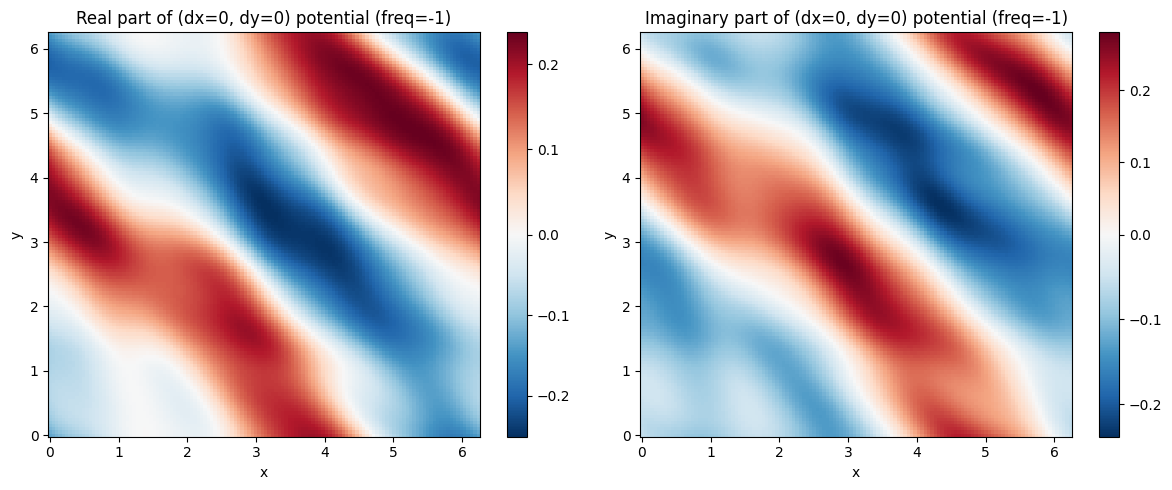

In [6]:
plot_potential(system, dx=0, dy=0, nx=128, ny=128)


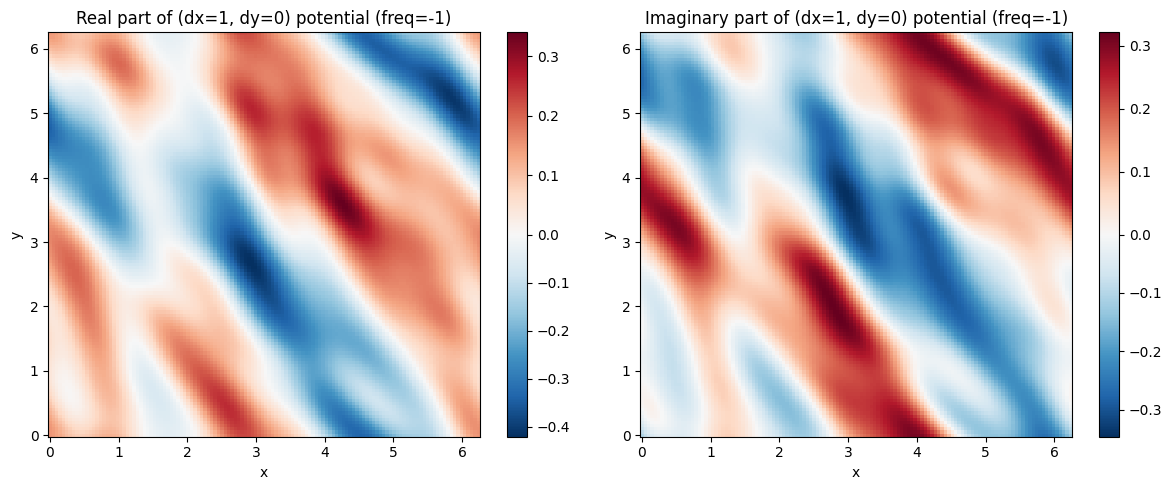

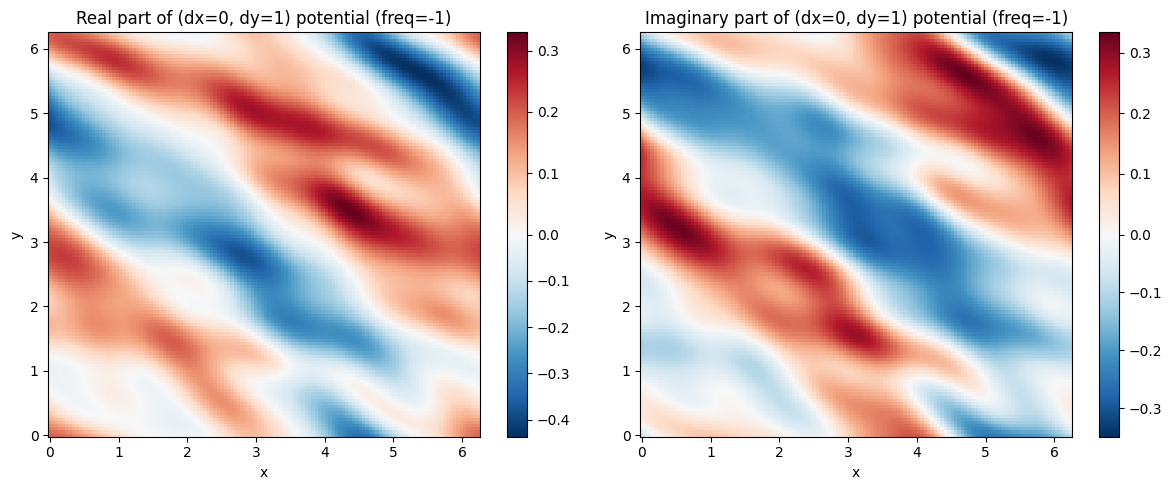

In [7]:
plot_potential(system, dx=1, dy=0, nx=128, ny=128)
plot_potential(system, dx=0, dy=1, nx=128, ny=128)


## 4. Reconstruir el potencial real dependiente del tiempo

`Potential` almacena los coeficientes espaciales. `PotentialSystem.hamiltonian(t, z)` reconstruye el valor real dependiente del tiempo.

Para trayectoria guiding-center (`type='gc'`), el Hamiltoniano coincide con la suma del potencial evaluado en las posiciones de todas las particulas.

In [8]:
def reconstruct_phi(system, t, x, y):
    phi_c = system.phic_interp(x, y)
    phi_t = np.zeros_like(np.asarray(x), dtype=float)
    if phi_c[0] is not None:
        phi_t += phi_c[0]
    if phi_c[1] is not None:
        for fluctuation, freq in zip(phi_c[1], system.freqs):
            phi_t += 2 * (fluctuation * np.exp(1j * freq * t)).real
    return phi_t

x0 = np.array([1.0])
y0 = np.array([2.0])
z0 = np.concatenate([x0, y0])

for t in [0.0, 0.5, 1.0]:
    phi_manual = reconstruct_phi(system, t, x0, y0)
    phi_hamiltonian = system.hamiltonian(t, z0)
    print(f't={t:3.1f} manual={phi_manual[0]: .6f} hamiltonian={phi_hamiltonian: .6f}')

t=0.0 manual= 0.195776 hamiltonian= 0.195776
t=0.5 manual= 0.075673 hamiltonian= 0.075673
t=1.0 manual=-0.062958 hamiltonian=-0.062958


## 5. Ecuaciones guiding-center

Para `traj['type'] == 'gc'`, `PotentialSystem.y_dot` devuelve:

- `x_dot = - dphi/dy`;
- `y_dot = dphi/dx`.

La celda siguiente compara `y_dot` con una reconstruccion manual usando derivadas interpoladas.

In [9]:
def reconstruct_gradient(system, t, x, y):
    dphidx_c = system.phic_interp(x, y, dx=1)
    dphidy_c = system.phic_interp(x, y, dy=1)
    dphidx = np.zeros_like(np.asarray(x), dtype=float)
    dphidy = np.zeros_like(np.asarray(y), dtype=float)
    if dphidx_c[0] is not None:
        dphidx += dphidx_c[0]
        dphidy += dphidy_c[0]
    if dphidx_c[1] is not None:
        for fluct_x, fluct_y, freq in zip(dphidx_c[1], dphidy_c[1], system.freqs):
            phase = 2 * np.exp(1j * freq * t)
            dphidx += (fluct_x * phase).real
            dphidy += (fluct_y * phase).real
    return dphidx, dphidy

t = 0.25
dphidx, dphidy = reconstruct_gradient(system, t, x0, y0)
manual_zdot = np.concatenate([-dphidy, dphidx])
system_zdot = system.y_dot(t, z0)

print('manual:', manual_zdot)
print('system:', system_zdot)
print('close:', np.allclose(manual_zdot, system_zdot))

manual: [-0.29319719  0.13913334]
system: [-0.29319719  0.13913334]
close: True


## 6. Reinterpolar cambiando resolucion

Si se pasa `nx` o `ny` al constructor de `Potential`, primero crea interpoladores en la malla original y despues genera campos en una malla nueva.

Esto se usa tambien desde `extract_potential(..., nx=..., ny=...)`.

In [10]:
pot_hi = Potential(
    pot.x,
    pot.y,
    pot.fields,
    pot.freqs,
    nx=96,
    ny=96,
    xy_period=pot.xy_period,
    k=pot.kinterp,
)

print('original:', pot.fields[1][0].shape, pot.dx, pot.dy)
print('reinterpolado:', pot_hi.fields[1][0].shape, pot_hi.dx, pot_hi.dy)

original: (64, 64) 0.09817477042468103 0.09817477042468103
reinterpolado: (96, 96) 0.06510537407110427 0.06510537407110427


## 7. Gyroaverage

`gyroaverage(rho, fields)` aplica en Fourier el factor `J0(2*pi*rho*k)`. El efecto practico es suavizar componentes espaciales dependiendo de `rho`.

`PotentialSystem` lo aplica automaticamente cuando `traj['rho'] != 0`.

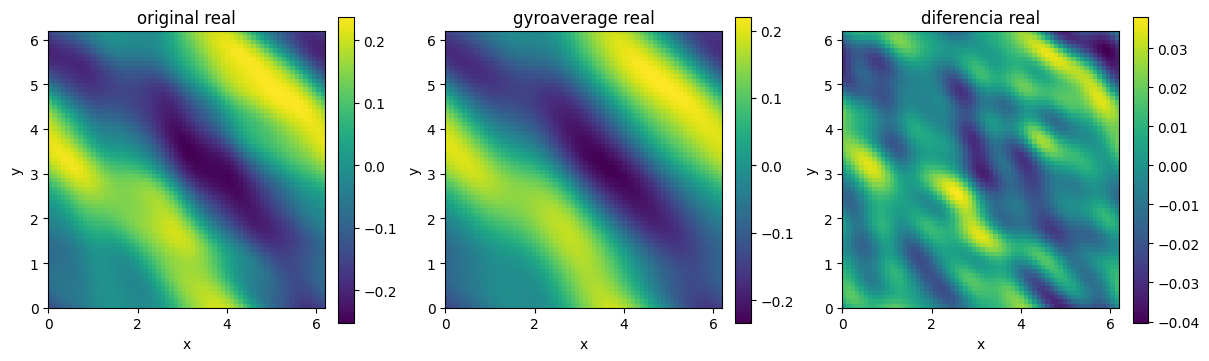

In [11]:
gyro_fields = pot.gyroaverage(rho=0.35, fields=pot.fields)
gyro_fluct = gyro_fields[1][0]

fig, axs = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
items = [
    (fluct.real, 'original real'),
    (gyro_fluct.real, 'gyroaverage real'),
    ((fluct - gyro_fluct).real, 'diferencia real'),
]
for ax, (data, title) in zip(axs, items):
    im = ax.imshow(data.T, origin='lower', extent=[pot.xmin, pot.xmax, pot.ymin, pot.ymax])
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(im, ax=ax)
plt.show()

## 8. Leer desde HDF5 con `extract_potential`

`extract_potential` espera un archivo con datasets:

- `Rcells`: malla x;
- `Zcells`: malla y;
- `freqs`: frecuencias;
- `fields`: array con shape `(len(freqs), len(y), len(x))`.

El helper hace varios pasos antes de crear `Potential`:

- separa frecuencia cero como valor medio;
- elimina frecuencias negativas;
- ordena las fluctuaciones por amplitud descendente;
- reescala por `omega * B`, usando la frecuencia dominante despues de ordenar;
- permite seleccionar indices con `indx`, donde `0` significa conservar la media.

In [12]:
with tempfile.TemporaryDirectory() as tmpdir:
    h5_path = Path(tmpdir) / 'example_potential.h5'
    x = np.linspace(0, 1, 32)
    y = np.linspace(0, 1, 32)
    X, Y = np.meshgrid(x, y, indexing='ij')

    mean = np.sin(2 * np.pi * X) * np.cos(2 * np.pi * Y)
    fluct_1 = 0.20 * np.exp(1j * 2 * np.pi * (X + Y))
    fluct_2 = 0.05 * np.exp(1j * 2 * np.pi * (2 * X - Y))

    freqs = np.array([0.0, 3.0, -4.0, 1.0])
    fields = np.stack([mean, fluct_1, np.conj(fluct_1), fluct_2])

    with h5py.File(h5_path, 'w') as f:
        f['Rcells'] = x
        f['Zcells'] = y
        f['freqs'] = freqs
        f['fields'] = fields

    extracted = extract_potential(h5_path, B=2, indx=[0, 1, 2], denoising=False)

print('freqs despues de filtrar/ordenar/seleccionar:', extracted.freqs)
print('mean shape:', extracted.fields[0].shape if extracted.fields[0] is not None else None)
print('number of fluctuations:', len(extracted.fields[1]) if extracted.fields[1] is not None else 0)
print('fluctuation shape:', extracted.fields[1][0].shape)

freqs despues de filtrar/ordenar/seleccionar: [3. 1.]
mean shape: (32, 32)
number of fluctuations: 2
fluctuation shape: (32, 32)


## 9. Checklist mental

Cuando algo falla con `Potential`, revisar en este orden:

1. `x` e `y` deben ser 1D, crecientes y uniformemente espaciados.
2. `fields` debe tener exactamente dos elementos: `[mean_value, fluctuations]`.
3. `mean_value` puede ser `None` o un array 2D.
4. `fluctuations` puede ser `None` o una lista de arrays complejos 2D.
5. `len(freqs)` debe coincidir con el numero de fluctuaciones usadas por `PotentialSystem`.
6. Si se usa `rho`, el orden `k` de interpolacion debe cumplir `min(k * dx, k * dy) >= rho`.